In [24]:
import pandas as pd
import json
from util.load import DataLoader
from tqdm import tqdm
import seaborn as sns

In [11]:
dataloader = DataLoader(data_dir="../data")
ticker = "kxhighny"
max_days = 300
full_df = dataloader.load_consolidated_daily_data(
    ticker, max_days=max_days, type_="processed"
)
daily_df = dataloader.load_daily_data(ticker, max_days=max_days, type_="processed")
full_df.drop(columns=["time", "ticker", "trade_id"]).head()

Loading kxhighny for 2025-06-05: 100%|██████████| 294/294 [00:01<00:00, 257.57it/s]


,time_to_strike,count,shift,kalshi_fair,forecast,yes_price,no_price,taker_side,kalshi_strike_delta,forecast_strike_delta,...,strike_m_5.0,strike_m_3.0,strike_m_1.0,strike_p_1.0,strike_p_3.0,strike_p_5.0,entropy,impact,result,outcome
0,135720.433,25,1.0,88.5,87.55,38,62,1,0.0,-0.95,...,0.0,0.0,0.0,38.0,0.0,0.0,-138.228,-35.000,-38,0
1,135700.506,11,1.0,88.5,87.55,38,62,1,0.0,-0.95,...,0.0,0.0,0.0,38.0,0.0,0.0,-138.228,-35.097,-38,0
2,135700.506,13,1.0,88.5,87.55,40,60,1,0.0,-0.95,...,0.0,0.0,0.0,40.0,0.0,0.0,-147.555,-37.057,-40,0
3,135608.070,24,1.0,88.5,87.55,39,61,1,0.0,-0.95,...,0.0,0.0,0.0,39.0,0.0,0.0,-142.879,-36.143,-39,0
4,135599.038,24,1.0,88.5,87.55,39,61,1,0.0,-0.95,...,0.0,0.0,0.0,39.0,0.0,0.0,-142.879,-35.544,-39,0


In [12]:
for date, df in tqdm(daily_df.items()):
    df['delta'] = df.groupby('shift')['yes_price'].transform(lambda x: x.diff()).fillna(0)

100%|██████████| 294/294 [00:00<00:00, 1044.16it/s]


In [20]:
delta_df = {
    'time': [],
    'delta_m_5.0': [],
    'delta_m_3.0': [],
    'delta_m_1.0': [],
    'delta_p_1.0': [],
    'delta_p_3.0': [],
    'delta_p_5.0': [],
}


for date, df in tqdm(daily_df.items()):
    delta = {k: 0 for k in delta_df.keys() if k != 'time'}
    for i in range(len(df) - 1, -1, -1):
        row = df.iloc[i]
        shift = row['shift']
        
        if float(shift) < 0:
            delta[f'delta_m_{abs(shift)}'] = row['delta']
        if float(shift) > 0:
            delta[f'delta_p_{shift}'] = row['delta']
        for k, v in delta.items():
            delta_df[k].append(v)
        delta_df['time'].append(row['time'])

delta_df = pd.DataFrame(delta_df)
delta_df = delta_df.sort_values(by='time')
delta_df

100%|██████████| 294/294 [00:07<00:00, 38.13it/s]


,time,delta_m_5.0,delta_m_3.0,delta_m_1.0,delta_p_1.0,delta_p_3.0,delta_p_5.0
130,2024-08-15 10:16:59.567171,0.0,0.0,0.0,0.0,0.0,0.0
129,2024-08-15 10:17:19.493700,0.0,0.0,0.0,0.0,0.0,0.0
128,2024-08-15 10:17:19.493700,0.0,0.0,0.0,2.0,0.0,0.0
127,2024-08-15 10:18:51.930135,0.0,0.0,0.0,-1.0,0.0,0.0
126,2024-08-15 10:19:00.962388,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
424618,2025-06-05 19:30:09.050584,0.0,0.0,0.0,-1.0,0.0,0.0
424617,2025-06-05 19:55:50.563286,0.0,0.0,0.0,-1.0,0.0,0.0
424616,2025-06-05 22:32:18.556538,0.0,0.0,0.0,0.0,0.0,0.0
424615,2025-06-05 23:08:33.405266,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
delta_df.describe()

,time,delta_m_5.0,delta_m_3.0,delta_m_1.0,delta_p_1.0,delta_p_3.0,delta_p_5.0
count,426643,426643.000000,426643.000000,426643.000000,426643.000000,426643.000000,426643.000000
mean,2025-02-02 00:19:54.650662912,-0.404010,-0.254459,-0.286399,-0.234027,-0.164869,-0.202197
min,2024-08-15 10:16:59.567171,-95.000000,-82.000000,-97.000000,-96.000000,-96.000000,-98.000000
25%,2024-11-28 08:00:05.366181120,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,2025-02-02 19:39:35.174232064,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2025-04-03 12:09:38.221992192,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,2025-06-05 23:08:33.405266,94.000000,94.000000,98.000000,98.000000,96.000000,98.000000
std,NaN,4.574463,3.885404,5.163092,5.828911,5.623699,4.660482


<Axes: >

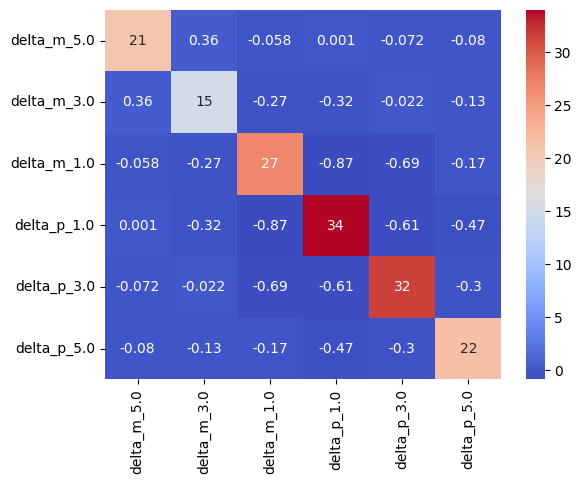

In [27]:
features = ['delta_m_5.0', 'delta_m_3.0', 'delta_m_1.0', 'delta_p_1.0', 'delta_p_3.0', 'delta_p_5.0']

covariance_matrix = delta_df[features].cov()
sns.heatmap(covariance_matrix, annot=True, cmap='coolwarm')